# Lecture 7: Multifactor Models, APT, and Real Factor Data

## Investment Analysis

This lecture gives a concise introduction to **arbitrage pricing theory**, or APT, and modern multifactor models.

The core idea is:

> Expected returns should compensate investors for exposure to systematic risk factors, not for diversifiable firm-specific noise.

CAPM uses one priced factor: the market portfolio. APT allows several priced factors and uses a no-arbitrage argument rather than the full CAPM equilibrium story.

> **Update note.** This notebook now uses the uploaded local JKP CSV file directly:
>
> `[usa]_[all_themes]_[monthly]_[vw_cap].csv`
>
> The live JKP URL-discovery workflow has been removed from the main teaching path. The real JKP factor data are loaded, pivoted, summarized, plotted, and analyzed in executed cells.

## 1. Roadmap

We proceed in five steps.

1. Arbitrage, no-arbitrage, and the law of one price.
2. The single-factor APT.
3. Diversification and well-diversified portfolios.
4. Multifactor APT and factor portfolios.
5. Empirical factor models: Fama-French, momentum, profitability, investment, smart beta, and the factor zoo.

## Revised Lecture Flow

This reorganized lecture follows a more natural sequence.

1. **No-arbitrage logic**: law of one price, pure arbitrage, risk arbitrage, zero-net-investment strategies.
2. **APT theory**: single-factor and multifactor models, well-diversified portfolios, factor loadings, and expected returns.
3. **Empirical factor models**: Fama-French, momentum, profitability, investment, smart beta, and the factor zoo.
4. **Real data lab**: download factor returns from the Ken French Data Library and JKP factor data, then compute summary statistics, cumulative returns, correlations, and factor regressions.
5. **Spurious factor simulation**: show why factor discovery can produce false positives when many factors are tested.

The lecture is concise, but it gives students enough code to continue exploring factor portfolios on their own.

## 2. Setup

The Python examples use synthetic data. This keeps the economics visible and avoids dependence on external data sources.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-pqoq56u_ because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


# Part I. Arbitrage and No-Arbitrage

## 3. Arbitrage

An **arbitrage opportunity** is a trading strategy with:

1. no net investment today,
2. no possibility of future loss,
3. a positive probability of future gain.

Formally, a payoff vector \(X\) is an arbitrage if:

$$
\text{Cost}(X) \le 0,
$$

$$
X_s \ge 0 \quad \text{for every state } s,
$$

and:

$$
X_s > 0 \quad \text{for at least one state } s.
$$

No-arbitrage says such opportunities cannot persist in competitive financial markets.

## 4. Law of One Price

The **law of one price** says that two assets with identical payoffs must have the same price.

If two assets have the same payoff in every state:

$$
X_A = X_B,
$$

then no-arbitrage requires:

$$
P_A = P_B.
$$

If \(P_A < P_B\), an investor could buy \(A\), short \(B\), pay negative net cost today, and have zero net payoff tomorrow. That is arbitrage.

In [2]:
# Law of one price example
states = ["Recession", "Normal", "Boom"]
A_payoff = np.array([90, 110, 130])
B_payoff = np.array([90, 110, 130])
P_A = 100
P_B = 104

strategy_payoff = A_payoff - B_payoff
strategy_cost = P_A - P_B

pd.DataFrame({
    "State": states,
    "Asset A Payoff": A_payoff,
    "Asset B Payoff": B_payoff,
    "Long A / Short B Payoff": strategy_payoff
}), strategy_cost

(       State  Asset A Payoff  Asset B Payoff  Long A / Short B Payoff
 0  Recession              90              90                        0
 1     Normal             110             110                        0
 2       Boom             130             130                        0,
 -4)

The strategy costs \(-4\) today because the investor receives \(104\) from shorting \(B\) and pays \(100\) to buy \(A\). The future payoff is zero in every state. That violates no-arbitrage.

## 5. Pure Arbitrage versus Risk Arbitrage

**Pure arbitrage** is riskless. It involves no possibility of loss under the assumed payoff structure.

**Risk arbitrage** is not truly arbitrage in the strict theoretical sense. It usually refers to trades that appear to exploit mispricing but still involve risk.

Examples of risk arbitrage include:

- merger arbitrage,
- convertible arbitrage,
- statistical arbitrage,
- pairs trading.

These strategies may have attractive expected returns, but they can lose money. They are better understood as risky trading strategies, not pure arbitrage.

## 6. Arbitrage versus Risk-Return Dominance

APT is based on no-arbitrage logic, not merely a preference-based claim that one investment has a better risk-return tradeoff.

A **dominance argument** says:

> Rational investors prefer more expected return and less risk.

An **arbitrage argument** says:

> A zero-net-investment strategy cannot deliver nonnegative payoffs in all states and positive payoffs in some states.

Dominance depends on investor preferences. Pure arbitrage does not.

# Part II. The Single-Factor APT

## 7. The Single-Factor Return Model

Suppose returns follow:

$$
R_i = \mathbb{E}[R_i] + \beta_i F + \epsilon_i,
$$

where:

- \(F\) is a common factor shock with \(\mathbb{E}[F]=0\),
- \(\beta_i\) is the factor loading or factor beta,
- \(\epsilon_i\) is firm-specific risk,
- \(\mathbb{E}[\epsilon_i]=0\),
- residuals are diversifiable in large portfolios.

The factor loading \(\beta_i\) measures sensitivity to the common factor.

## 8. Single-Factor APT Expected Return Relation

In a single-factor APT economy, expected returns should satisfy:

$$
\mathbb{E}[R_i] = R_f + \beta_i \lambda,
$$

where:

- \(R_f\) is the risk-free rate,
- \(\lambda\) is the factor risk premium,
- \(\beta_i\) is asset \(i\)'s exposure to the factor.

This is the **APT security market line**.

If the factor is the market excess return, this resembles the CAPM. But APT does not require the market portfolio to be mean-variance efficient.

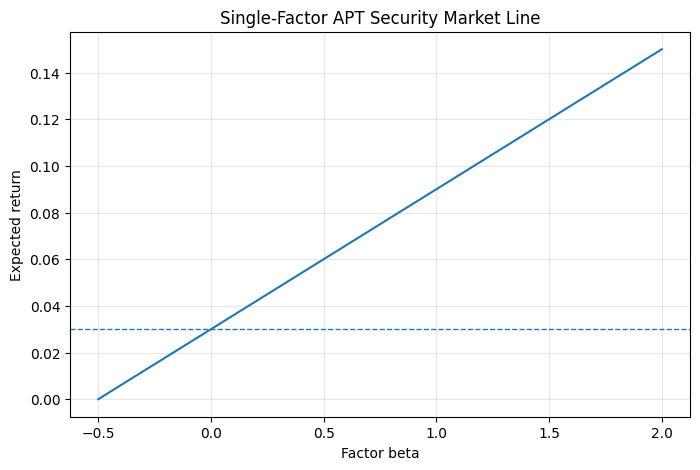

In [3]:
# Single-factor APT line
rf = 0.03
lambda_factor = 0.06
betas = np.linspace(-0.5, 2.0, 100)
expected_returns = rf + betas * lambda_factor

plt.figure(figsize=(8,5))
plt.plot(betas, expected_returns)
plt.axhline(rf, linestyle="--", linewidth=1)
plt.xlabel("Factor beta")
plt.ylabel("Expected return")
plt.title("Single-Factor APT Security Market Line")
plt.grid(True, alpha=0.3)
plt.show()

## 9. Factor Loadings and Covariance

In the single-factor model:

$$
R_i = \mathbb{E}[R_i] + \beta_iF + \epsilon_i.
$$

Assuming residuals are uncorrelated with the factor and with each other, covariance between assets \(i\) and \(j\) is:

$$
\operatorname{Cov}(R_i,R_j)=\beta_i\beta_j\sigma_F^2.
$$

So two firms covary because both are exposed to the same systematic factor.

In [4]:
# Covariance implied by factor loadings
sigma_F = 0.18
beta_i = 1.3
beta_j = 0.7
cov_ij = beta_i * beta_j * sigma_F**2
cov_ij

0.029483999999999996

# Part III. Diversification and the APT Argument

## 10. Well-Diversified Portfolios

A portfolio is **well diversified** when firm-specific risks largely cancel out.

If residual risks are independent, an equally weighted portfolio of \(N\) securities has residual variance:

$$
\operatorname{Var}(\epsilon_p)=\frac{\sigma_\epsilon^2}{N}.
$$

As \(N\) becomes large:

$$
\operatorname{Var}(\epsilon_p) \to 0.
$$

The portfolio still has factor risk, but little firm-specific risk.

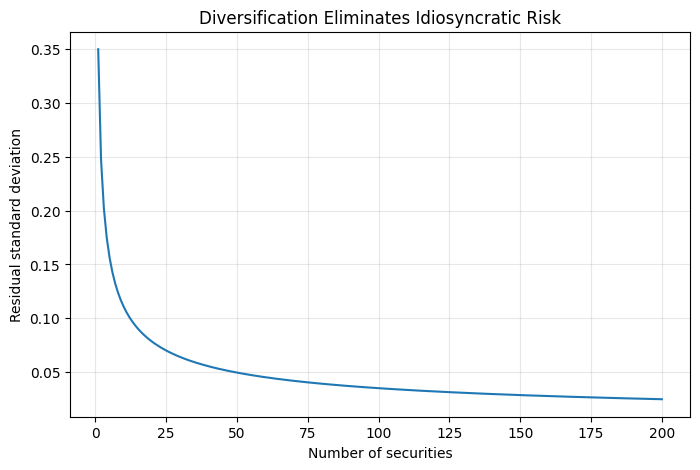

In [5]:
# Diversification of residual risk
N = np.arange(1, 201)
sigma_eps = 0.35
resid_std = sigma_eps / np.sqrt(N)

plt.figure(figsize=(8,5))
plt.plot(N, resid_std)
plt.xlabel("Number of securities")
plt.ylabel("Residual standard deviation")
plt.title("Diversification Eliminates Idiosyncratic Risk")
plt.grid(True, alpha=0.3)
plt.show()

## 11. Ross's APT Assumptions

Ross's APT relies on a few central assumptions:

1. Security returns are generated by a factor structure.
2. There are many securities, so idiosyncratic risk can be diversified away.
3. Investors prefer more wealth to less wealth.
4. No arbitrage opportunities persist.
5. Markets are sufficiently competitive for arbitrage pressure to affect prices.

The APT does not require every investor to hold the market portfolio. It also does not require the market portfolio to be directly observed or mean-variance efficient.

## 12. Zero-Net-Investment Strategy

APT arbitrage arguments often use **zero-net-investment portfolios**.

A portfolio with weights \(w_i\) is zero-net-investment if:

$$
\sum_i w_i = 0.
$$

If it also has zero factor exposure:

$$
\sum_i w_i\beta_i = 0,
$$

then it has no systematic risk.

If it is well diversified, it also has little residual risk.

Therefore, it should not have a positive expected return. If it did, investors could scale it up into an arbitrage-like opportunity.

In [6]:
# Construct a zero-net-investment, zero-beta strategy from three assets
assets = pd.DataFrame({
    "Asset": ["A", "B", "C"],
    "Expected Return": [0.06, 0.09, 0.12],
    "Beta": [0.5, 1.0, 1.5]
})

# One simple zero-investment, zero-beta vector: long A and C, short 2B
weights = np.array([1, -2, 1])
assets["Strategy Weight"] = weights
assets["Weighted Beta"] = assets["Beta"] * weights
assets["Weighted Expected Return"] = assets["Expected Return"] * weights
assets, weights.sum(), assets["Weighted Beta"].sum(), assets["Weighted Expected Return"].sum()

(  Asset  Expected Return  ...  Weighted Beta  Weighted Expected Return
 0     A           0.0600  ...         0.5000                    0.0600
 1     B           0.0900  ...        -2.0000                   -0.1800
 2     C           0.1200  ...         1.5000                    0.1200
 
 [3 rows x 6 columns],
 np.int64(0),
 np.float64(0.0),
 np.float64(0.0))

The strategy has zero net investment and zero beta. If it has positive expected return and negligible residual risk, it violates the APT no-arbitrage condition.

## 13. What the APT Says About Individual Securities

Strictly speaking, the APT is most powerful for **well-diversified portfolios**.

For individual securities, firm-specific risk may be large. Therefore, an individual security can deviate from the APT line because its residual risk is not diversified.

But large pricing errors in many individual securities cannot persist if investors can combine them into diversified arbitrage portfolios.

So APT pricing is approximate for individual securities and tighter for diversified portfolios.

# Part IV. Multifactor APT

## 14. Multifactor Return Model

The multifactor APT model is:

$$
R_i = \mathbb{E}[R_i] + \beta_{i1}F_1 + \beta_{i2}F_2 + \cdots + \beta_{iK}F_K + \epsilon_i.
$$

The expected return relation is:

$$
\mathbb{E}[R_i]
=
R_f + \beta_{i1}\lambda_1 + \beta_{i2}\lambda_2 + \cdots + \beta_{iK}\lambda_K.
$$

Each factor premium \(\lambda_k\) is the reward for bearing exposure to factor \(k\).

## 15. Factor Portfolios

A **factor portfolio** is a portfolio designed to have exposure to one factor and little or no exposure to other factors.

A pure factor portfolio for factor \(k\) has:

$$
\beta_k = 1,
$$

and:

$$
\beta_j = 0 \quad \text{for } j\ne k.
$$

If such portfolios can be formed, their expected excess returns identify the factor risk premia.

## 16. Multifactor Arbitrage Logic

Consider a zero-net-investment portfolio with weights \(w_i\).

No net investment:

$$
\sum_i w_i = 0.
$$

Zero exposure to every factor:

$$
\sum_i w_i\beta_{ik}=0 \quad \text{for every factor } k.
$$

If the portfolio is well diversified, residual risk is negligible.

No-arbitrage then requires:

$$
\sum_i w_i\mathbb{E}[R_i]=0.
$$

If not, the portfolio would offer expected return without systematic risk or net investment.

In [7]:
# Multifactor expected returns
rf = 0.03
lambdas = np.array([0.05, 0.03, 0.02])  # market, size, value factor premia
B = pd.DataFrame({
    "Market beta": [0.8, 1.1, 1.4, 0.7],
    "Size beta":   [0.2, -0.1, 0.5, -0.3],
    "Value beta":  [-0.2, 0.4, 0.1, 0.6]
}, index=["Stock A", "Stock B", "Stock C", "Stock D"])

expected = rf + B.values @ lambdas
B["APT Expected Return"] = expected
B

,Market beta,Size beta,Value beta,APT Expected Return
Stock A,0.8000,0.2000,-0.2000,0.0720
Stock B,1.1000,-0.1000,0.4000,0.0900
Stock C,1.4000,0.5000,0.1000,0.1170
Stock D,0.7000,-0.3000,0.6000,0.0680


## 17. Estimating the Cost of Capital with APT

A firm or project with factor loadings \(\beta_1,\ldots,\beta_K\) has required return:

$$
r = R_f + \sum_{k=1}^K \beta_k\lambda_k.
$$

This can be used as a hurdle rate for capital budgeting.

A cyclical project may load heavily on market and credit factors. A small-growth project may load on size and investment factors. A regulated utility project may have lower market beta but perhaps strong interest-rate sensitivity.

The APT cost of capital is useful because project risk can be decomposed into multiple systematic sources.

In [8]:
# Project cost of capital using a three-factor APT model
project_betas = np.array([1.2, 0.4, -0.1])
project_required_return = rf + project_betas @ lambdas
project_required_return

np.float64(0.09999999999999999)

# Part V. CAPM versus APT

## 18. Similarities

CAPM and APT both imply that expected returns depend on systematic risk.

Both distinguish systematic risk from diversifiable idiosyncratic risk.

Both can be used to estimate a cost of capital.

Both can be represented as linear expected-return models.

## 19. Differences

| Topic | CAPM | APT |
|---|---|---|
| Main logic | Equilibrium with mean-variance investors | No-arbitrage with factor structure |
| Priced risks | Market beta | One or more factor betas |
| Market portfolio | Central and efficient | Not necessarily central |
| Number of factors | One | Potentially many |
| Strongest prediction | SML for all assets | Approximate pricing for diversified portfolios |
| Empirical flexibility | Low | High |

The CAPM is more restrictive and elegant. The APT is more flexible and empirically adaptable.

# Part VI. Empirical Multifactor Models

## 20. Fama-French Three-Factor Model

The Fama-French three-factor model is commonly written as:

$$
R_i - R_f
=
\alpha_i
+
\beta_{iM}(R_M-R_f)
+
s_i SMB
+
h_i HML
+
\epsilon_i.
$$

where:

- \(R_M-R_f\) is the market excess return,
- \(SMB\) is small-minus-big, a size factor,
- \(HML\) is high-minus-low, a value factor.

The model was introduced to explain patterns that the CAPM struggled with, especially size and value effects.

## 21. Momentum, Profitability, and Investment Factors

Common additional factors include:

**Momentum**: stocks that have performed well recently tend to continue outperforming over intermediate horizons.

**Profitability**: more profitable firms tend to earn higher average returns, controlling for other characteristics.

**Investment**: firms that invest conservatively often earn higher average returns than firms that invest aggressively.

The Fama-French five-factor model adds profitability and investment factors to the original three-factor structure.

In [9]:
# Simulate a Fama-French-style regression
T = 240
factors = pd.DataFrame({
    "MKT_RF": np.random.normal(0.006, 0.045, T),
    "SMB": np.random.normal(0.002, 0.030, T),
    "HML": np.random.normal(0.003, 0.035, T),
    "MOM": np.random.normal(0.004, 0.040, T)
})

true_alpha = 0.001
true_betas = np.array([1.1, 0.4, -0.2, 0.3])
epsilon = np.random.normal(0, 0.035, T)
asset_excess = true_alpha + factors.values @ true_betas + epsilon

X = np.column_stack([np.ones(T), factors.values])
bhat = np.linalg.inv(X.T @ X) @ X.T @ asset_excess
resid = asset_excess - X @ bhat
s2 = resid @ resid / (T - X.shape[1])
se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
tstats = bhat / se

pd.DataFrame({
    "Estimate": bhat,
    "Std Error": se,
    "t-stat": tstats,
    "True Value": np.r_[true_alpha, true_betas]
}, index=["Alpha", "MKT_RF", "SMB", "HML", "MOM"])

,Estimate,Std Error,t-stat,True Value
Alpha,0.0019,0.0024,0.7996,0.0010
MKT_RF,1.0070,0.0544,18.5249,1.1000
SMB,0.4954,0.0773,6.4108,0.4000
HML,-0.2172,0.0696,-3.1229,-0.2000
MOM,0.3475,0.0629,5.5212,0.3000


## 22. Ways to Identify Risk Factors

A proposed factor should have an economic rationale. Common approaches include:

1. **Macroeconomic factors**: inflation, industrial production, term spreads, credit spreads.
2. **Statistical factors**: principal components or latent factors extracted from returns.
3. **Characteristic-based factors**: size, value, momentum, profitability, investment, quality, low volatility.
4. **Theoretical factors**: factors motivated by consumption risk, investment risk, liquidity risk, or intermediary balance sheets.

A factor is more credible when it is persistent, robust, investable, economically interpretable, and not purely a product of data mining.

## 23. The Factor Zoo

The **factor zoo** refers to the large number of published return predictors and factors.

The danger is data mining. If researchers test enough variables, some will appear significant by chance.

A useful factor should pass demanding tests:

- survives out of sample,
- works across markets or periods,
- has low turnover and implementability,
- survives transaction costs,
- has an economic explanation,
- is not subsumed by better-known factors,
- remains useful after publication.

## 24. Smart Beta

**Smart beta** strategies are rules-based portfolios that tilt toward rewarded characteristics or factors.

Examples include:

- value,
- size,
- momentum,
- quality,
- low volatility,
- profitability,
- dividend yield,
- minimum volatility.

Smart beta sits between passive indexing and traditional active management.

It is passive in implementation because the rules are systematic. It is active in exposure because the portfolio differs from the market-cap-weighted index.

# 25. Concise Worked Example: APT Mispricing

Suppose the risk-free rate is 3%, and the factor premium is 6%.

For a stock with beta 1.2, APT requires:

$$
\mathbb{E}[R_i]=0.03+1.2(0.06)=0.102.
$$

So the required return is 10.2%.

If analysts forecast 13%, the stock has positive expected alpha:

$$
\alpha_i = 0.13-0.102=0.028.
$$

If this alpha is reliable and the idiosyncratic risk can be diversified, investors would want to overweight the stock.

In [10]:
rf = 0.03
lambda_m = 0.06
beta = 1.2
apt_required = rf + beta * lambda_m
forecast_return = 0.13
alpha = forecast_return - apt_required
pd.DataFrame({
    "Input": ["Risk-free rate", "Factor premium", "Beta", "APT required return", "Forecast return", "Forecast alpha"],
    "Value": [rf, lambda_m, beta, apt_required, forecast_return, alpha]
})

,Input,Value
0,Risk-free rate,0.0300
1,Factor premium,0.0600
2,Beta,1.2000
3,APT required return,0.1020
4,Forecast return,0.1300
5,Forecast alpha,0.0280


# Part VII. Real Factor Data Lab: Ken French and Local JKP Factors

This section uses the JKP factor CSV supplied with the notebook:

```text
[usa]_[all_themes]_[monthly]_[vw_cap].csv
```

This is better for teaching than trying to scrape the JKP website live. The notebook now reads the local CSV directly, reshapes the data into a factor-return matrix, and performs real factor analysis.

The file is in long format:

- `location`: market or country,
- `name`: factor name,
- `freq`: return frequency,
- `weighting`: portfolio weighting convention,
- `n_factors`: theme/group identifier,
- `date`: month-end date,
- `ret`: factor return.

The analysis below converts the file into a wide table with dates as rows and factor names as columns.

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# The uploaded CSV is available at this path in the generated notebook environment.
# If you move the notebook, keep the CSV in the same folder or update DATA_FILE.
DATA_FILE = Path("/mnt/data/[usa]_[all_themes]_[monthly]_[vw_cap].csv")

# Portable fallback: if running locally, look in the same folder as the notebook.
if not DATA_FILE.exists():
    DATA_FILE = Path("[usa]_[all_themes]_[monthly]_[vw_cap].csv")

print(f"Using JKP CSV file: {DATA_FILE}")
print(f"File exists: {DATA_FILE.exists()}")

Using JKP CSV file: /mnt/data/[usa]_[all_themes]_[monthly]_[vw_cap].csv
File exists: True


In [12]:
jkp_long = pd.read_csv(DATA_FILE, encoding="utf-8-sig")
jkp_long["date"] = pd.to_datetime(jkp_long["date"])

display(jkp_long.head())
display(jkp_long.tail())

print("Shape:", jkp_long.shape)
print("Columns:", list(jkp_long.columns))
print("Number of factor names:", jkp_long["name"].nunique())
print("Date range:", jkp_long["date"].min(), "to", jkp_long["date"].max())

,location,name,freq,weighting,n_factors,date,ret
0,usa,accruals,monthly,vw_cap,1,1946-01-31,0.0193
1,usa,accruals,monthly,vw_cap,1,1946-02-28,-0.0147
2,usa,accruals,monthly,vw_cap,1,1946-03-31,0.0413
3,usa,accruals,monthly,vw_cap,1,1946-04-30,0.0082
4,usa,accruals,monthly,vw_cap,1,1946-05-31,0.0216


,location,name,freq,weighting,n_factors,date,ret
14940,usa,value,monthly,vw_cap,18,2025-08-31,0.0296
14941,usa,value,monthly,vw_cap,18,2025-09-30,-0.0386
14942,usa,value,monthly,vw_cap,18,2025-10-31,-0.0399
14943,usa,value,monthly,vw_cap,18,2025-11-30,0.0488
14944,usa,value,monthly,vw_cap,18,2025-12-31,0.0175


Shape: (14945, 7)
Columns: ['location', 'name', 'freq', 'weighting', 'n_factors', 'date', 'ret']
Number of factor names: 13
Date range: 1926-01-31 00:00:00 to 2025-12-31 00:00:00


## Pivot the JKP Data into a Factor Return Matrix

Most factor analysis is easier when the data are in wide format:

$$
\text{rows} = \text{dates}, \qquad \text{columns} = \text{factor returns}.
$$

The code below pivots the long file into a matrix of monthly factor returns.

In [13]:
jkp_factors = (
    jkp_long
    .pivot_table(index="date", columns="name", values="ret", aggfunc="mean")
    .sort_index()
)

jkp_factors.index.name = "Date"

display(jkp_factors.head())
display(jkp_factors.tail())

print("Wide factor matrix shape:", jkp_factors.shape)
print("Factor columns:")
print(list(jkp_factors.columns))

name,accruals,debt_issuance,investment,low_leverage,low_risk,momentum,profit_growth,profitability,quality,seasonality,short_term_reversal,size,value
Date,,,,,,,,,,,,,
1926-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0183,NaN
1926-02-28,NaN,NaN,NaN,-0.0487,0.0323,NaN,NaN,NaN,NaN,-0.0026,0.0013,-0.0222,NaN
1926-03-31,NaN,NaN,NaN,-0.0775,0.0451,NaN,NaN,NaN,NaN,0.0041,-0.0293,-0.0488,NaN
1926-04-30,NaN,NaN,NaN,-0.0145,-0.0041,-0.0096,NaN,0.0066,NaN,0.0088,0.0024,-0.0029,NaN
1926-05-31,NaN,NaN,NaN,-0.0118,0.0024,0.0200,NaN,0.0020,NaN,0.0036,-0.0130,-0.0005,NaN


name,accruals,debt_issuance,investment,low_leverage,low_risk,momentum,profit_growth,profitability,quality,seasonality,short_term_reversal,size,value
Date,,,,,,,,,,,,,
2025-08-31,-0.0044,0.0040,0.0078,-0.0032,-0.0120,-0.0186,0.0002,-0.0115,-0.0112,0.0014,0.0012,0.0488,0.0296
2025-09-30,-0.0029,0.0040,-0.0114,0.0315,-0.0467,0.0565,0.0210,-0.0239,-0.0091,0.0031,-0.0054,0.0175,-0.0386
2025-10-31,-0.0038,0.0063,-0.0079,0.0402,-0.0593,0.0296,0.0042,-0.0392,-0.0068,0.0008,-0.0418,0.0114,-0.0399
2025-11-30,-0.0099,-0.0074,0.0149,-0.0364,0.0396,-0.0021,-0.0003,0.0294,0.0006,0.0114,0.0117,0.0105,0.0488
2025-12-31,-0.0011,0.0111,0.0078,-0.0010,-0.0011,-0.0144,0.0034,0.0041,-0.0100,0.0048,0.0033,0.0068,0.0175


Wide factor matrix shape: (1200, 13)
Factor columns:
['accruals', 'debt_issuance', 'investment', 'low_leverage', 'low_risk', 'momentum', 'profit_growth', 'profitability', 'quality', 'seasonality', 'short_term_reversal', 'size', 'value']


## Summary of the Uploaded JKP Factor File

Before analyzing returns, inspect the metadata.

This confirms that the file is the U.S. monthly `vw_cap` version and shows how many observations are available for each factor.

In [14]:
metadata_summary = (
    jkp_long
    .groupby(["location", "freq", "weighting", "name"])
    .agg(
        observations=("ret", "size"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        mean_monthly_return=("ret", "mean"),
        monthly_volatility=("ret", "std")
    )
    .reset_index()
)

display(metadata_summary)

,location,freq,weighting,name,observations,start_date,end_date,mean_monthly_return,monthly_volatility
0,usa,monthly,vw_cap,accruals,960,1946-01-31,2025-12-31,0.0022,0.0116
1,usa,monthly,vw_cap,debt_issuance,890,1951-11-30,2025-12-31,0.0020,0.0070
2,usa,monthly,vw_cap,investment,1140,1931-01-31,2025-12-31,0.0031,0.0275
3,usa,monthly,vw_cap,low_leverage,1199,1926-02-28,2025-12-31,0.0002,0.0272
4,usa,monthly,vw_cap,low_risk,1199,1926-02-28,2025-12-31,0.0008,0.0392
5,usa,monthly,vw_cap,momentum,1197,1926-04-30,2025-12-31,0.0032,0.0383
6,usa,monthly,vw_cap,profit_growth,1188,1927-01-31,2025-12-31,0.0028,0.0231
7,usa,monthly,vw_cap,profitability,1197,1926-04-30,2025-12-31,0.0019,0.0231
8,usa,monthly,vw_cap,quality,1188,1927-01-31,2025-12-31,0.0021,0.0355
9,usa,monthly,vw_cap,seasonality,1199,1926-02-28,2025-12-31,0.0011,0.0113


## Annualized Factor Summary Statistics

For monthly returns, the usual annualization formulas are:

$$
\mu_{ann} = 12\bar{r}_{monthly}
$$

and:

$$
\sigma_{ann} = \sqrt{12}\sigma_{monthly}.
$$

The Sharpe ratio reported here uses the factor return itself as an excess return, which is appropriate for long-short factor portfolios when `ret` is already excess or self-financing.

In [15]:
def annualized_factor_summary(factors, periods_per_year=12):
    factors = factors.copy().dropna(axis=1, how="all")
    out = pd.DataFrame(index=factors.columns)
    out["Mean Ann. Return"] = factors.mean() * periods_per_year
    out["Ann. Volatility"] = factors.std(ddof=1) * np.sqrt(periods_per_year)
    out["Sharpe Ratio"] = out["Mean Ann. Return"] / out["Ann. Volatility"]
    out["Skewness"] = factors.skew()
    out["Excess Kurtosis"] = factors.kurtosis()
    out["Worst Monthly Return"] = factors.min()
    out["Best Monthly Return"] = factors.max()
    out["Observations"] = factors.count()
    out["Start"] = factors.apply(lambda x: x.dropna().index.min())
    out["End"] = factors.apply(lambda x: x.dropna().index.max())
    return out.sort_values("Sharpe Ratio", ascending=False)

jkp_summary = annualized_factor_summary(jkp_factors)
display(jkp_summary)

,Mean Ann. Return,Ann. Volatility,Sharpe Ratio,Skewness,Excess Kurtosis,Worst Monthly Return,Best Monthly Return,Observations,Start,End
name,,,,,,,,,,
debt_issuance,0.0236,0.0243,0.9716,0.8498,9.4854,-0.0327,0.0673,890,1951-11-30,2025-12-31
accruals,0.0263,0.0401,0.6557,0.2296,1.3692,-0.0458,0.0471,960,1946-01-31,2025-12-31
short_term_reversal,0.0294,0.0484,0.6062,-0.5216,22.6856,-0.1552,0.1109,1199,1926-02-28,2025-12-31
profit_growth,0.0340,0.0801,0.4246,-5.3919,83.9485,-0.3615,0.1292,1188,1927-01-31,2025-12-31
investment,0.0371,0.0954,0.3885,2.8458,29.1479,-0.1625,0.2993,1140,1931-01-31,2025-12-31
seasonality,0.0135,0.0390,0.3457,-5.2651,83.7445,-0.1864,0.0576,1199,1926-02-28,2025-12-31
profitability,0.0232,0.0800,0.2902,0.4682,14.9594,-0.1697,0.1788,1197,1926-04-30,2025-12-31
momentum,0.0380,0.1326,0.2864,-3.6982,41.7205,-0.4923,0.2333,1197,1926-04-30,2025-12-31
value,0.0289,0.1074,0.2690,-0.8243,18.3834,-0.2811,0.2106,1189,1926-12-31,2025-12-31


## Cumulative Returns for the Factor Portfolios

To visualize long-run factor performance, compound the monthly factor returns:

$$
W_t = \prod_{s=1}^{t}(1+r_s).
$$

Because these are long-short factor returns, the wealth index should be interpreted as the growth of a stylized factor strategy, not as a directly investable product net of trading costs.

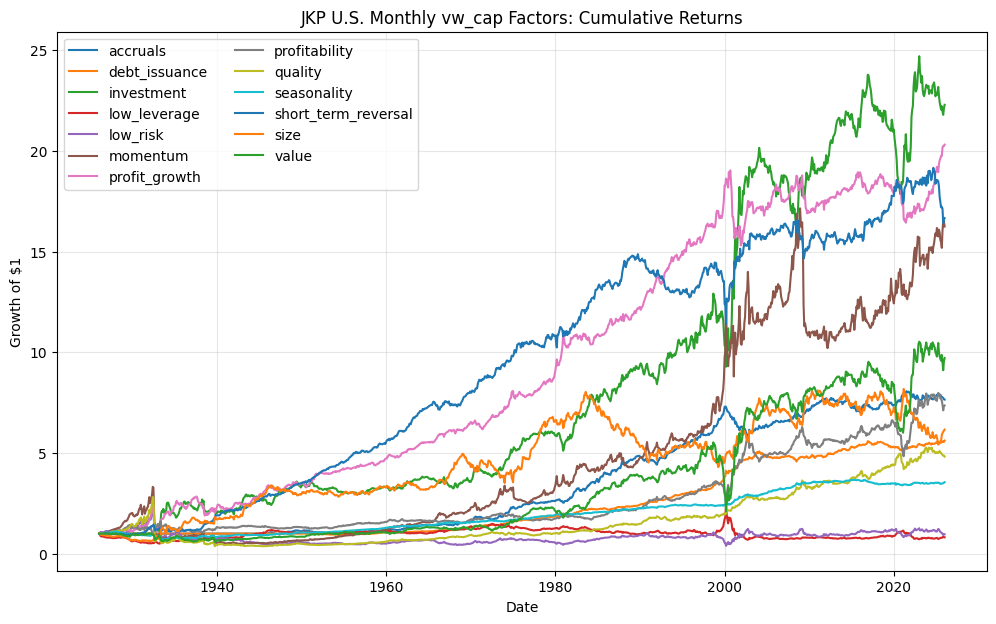

In [16]:
def plot_cumulative_factor_returns(factors, title="Cumulative Factor Returns", start=None):
    x = factors.copy()
    if start is not None:
        x = x.loc[x.index >= pd.to_datetime(start)]
    wealth = (1 + x.fillna(0)).cumprod()

    plt.figure(figsize=(12, 7))
    for col in wealth.columns:
        plt.plot(wealth.index, wealth[col], label=str(col))
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.title(title)
    plt.legend(ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()
    return wealth

wealth_all = plot_cumulative_factor_returns(
    jkp_factors,
    title="JKP U.S. Monthly vw_cap Factors: Cumulative Returns"
)

## Top and Bottom Factors by Historical Sharpe Ratio

A factor with a high historical Sharpe ratio is not automatically a good investment.

It may reflect:

- compensation for bearing systematic risk,
- market inefficiency,
- behavioral mispricing,
- institutional frictions,
- data mining,
- omitted transaction costs,
- capacity limitations.

Still, ranking factors is a useful first empirical exercise.

In [17]:
top_factors = jkp_summary.head(5).index.tolist()
bottom_factors = jkp_summary.tail(5).index.tolist()

print("Top factors by historical Sharpe ratio:")
print(top_factors)

print("\nBottom factors by historical Sharpe ratio:")
print(bottom_factors)

display(jkp_summary.loc[top_factors + bottom_factors])

Top factors by historical Sharpe ratio:
['debt_issuance', 'accruals', 'short_term_reversal', 'profit_growth', 'investment']

Bottom factors by historical Sharpe ratio:
['value', 'size', 'quality', 'low_risk', 'low_leverage']


,Mean Ann. Return,Ann. Volatility,Sharpe Ratio,Skewness,Excess Kurtosis,Worst Monthly Return,Best Monthly Return,Observations,Start,End
name,,,,,,,,,,
debt_issuance,0.0236,0.0243,0.9716,0.8498,9.4854,-0.0327,0.0673,890,1951-11-30,2025-12-31
accruals,0.0263,0.0401,0.6557,0.2296,1.3692,-0.0458,0.0471,960,1946-01-31,2025-12-31
short_term_reversal,0.0294,0.0484,0.6062,-0.5216,22.6856,-0.1552,0.1109,1199,1926-02-28,2025-12-31
profit_growth,0.0340,0.0801,0.4246,-5.3919,83.9485,-0.3615,0.1292,1188,1927-01-31,2025-12-31
investment,0.0371,0.0954,0.3885,2.8458,29.1479,-0.1625,0.2993,1140,1931-01-31,2025-12-31
value,0.0289,0.1074,0.2690,-0.8243,18.3834,-0.2811,0.2106,1189,1926-12-31,2025-12-31
size,0.0229,0.1013,0.2264,4.8786,61.3546,-0.1066,0.4570,1200,1926-01-31,2025-12-31
quality,0.0255,0.1228,0.2075,-6.7980,99.5833,-0.5922,0.1527,1188,1927-01-31,2025-12-31
low_risk,0.0092,0.1357,0.0679,-1.0044,10.8753,-0.2832,0.2216,1199,1926-02-28,2025-12-31


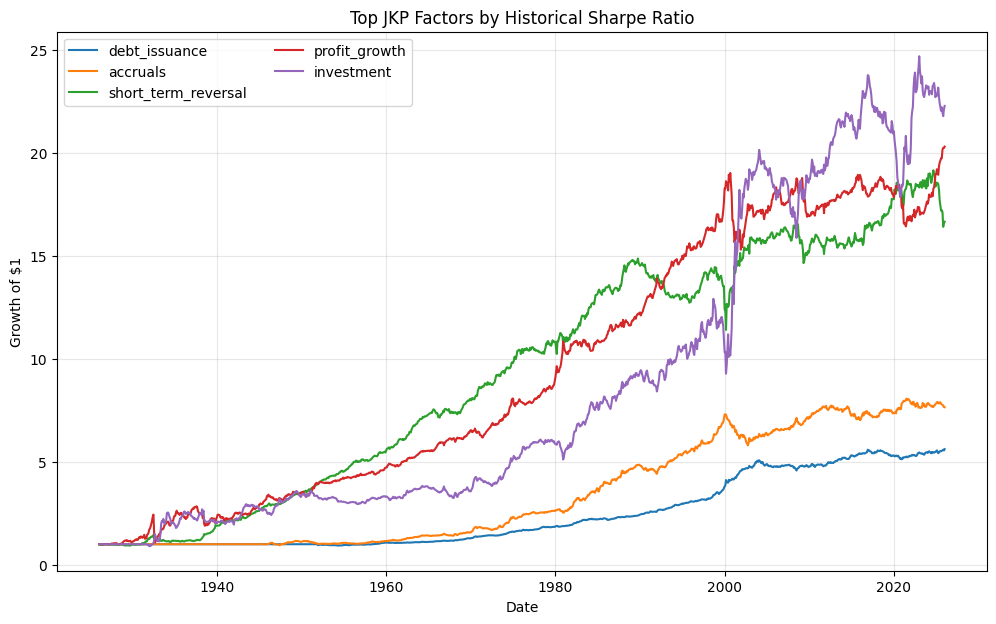

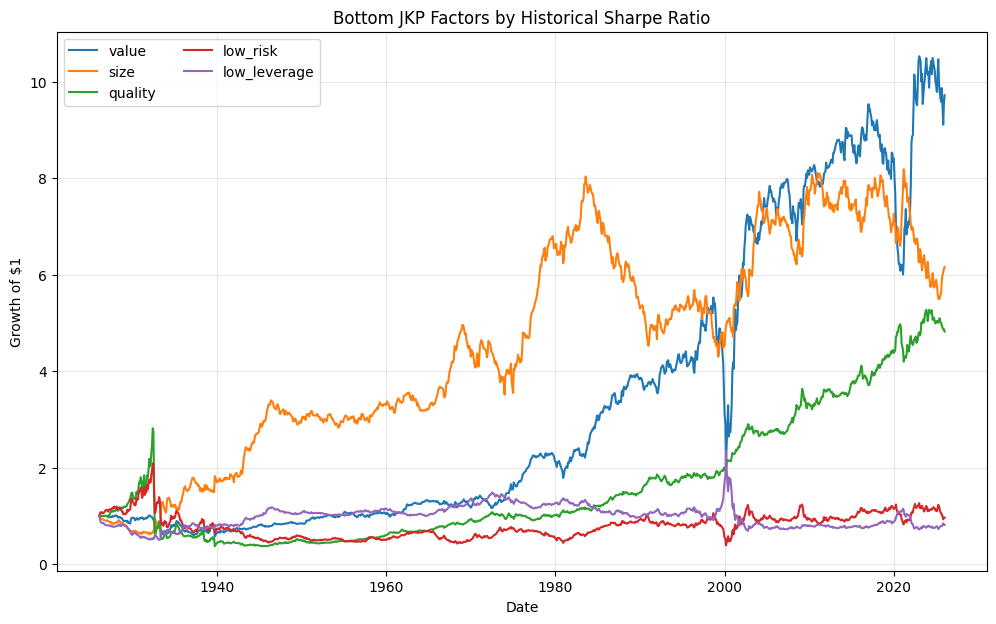

In [18]:
wealth_top = plot_cumulative_factor_returns(
    jkp_factors[top_factors],
    title="Top JKP Factors by Historical Sharpe Ratio"
)

wealth_bottom = plot_cumulative_factor_returns(
    jkp_factors[bottom_factors],
    title="Bottom JKP Factors by Historical Sharpe Ratio"
)

## Factor Correlations

A multifactor model is more useful when factors are not merely duplicates.

The correlation matrix helps answer whether different factors capture distinct return patterns.

Highly correlated factors may represent similar economic mechanisms or overlapping portfolio construction rules.

name,accruals,debt_issuance,investment,low_leverage,low_risk,momentum,profit_growth,profitability,quality,seasonality,short_term_reversal,size,value
name,,,,,,,,,,,,,
accruals,1.0000,0.1522,0.2299,-0.0082,0.0330,-0.0003,-0.1203,-0.2965,-0.3077,0.0547,-0.0621,0.0602,0.0716
debt_issuance,0.1522,1.0000,0.1689,0.2897,-0.1735,0.2263,0.1668,-0.2044,0.1095,-0.0174,-0.1719,0.1583,-0.1693
investment,0.2299,0.1689,1.0000,-0.2120,0.1269,-0.1879,-0.2362,0.0712,-0.3918,-0.1161,-0.1114,0.3621,0.2576
low_leverage,-0.0082,0.2897,-0.2120,1.0000,-0.7424,-0.1366,0.0292,-0.4152,-0.1986,-0.1676,-0.2355,0.4669,-0.8365
low_risk,0.0330,-0.1735,0.1269,-0.7424,1.0000,0.3912,0.2112,0.1199,0.5305,0.4262,0.2692,-0.4846,0.7157
momentum,-0.0003,0.2263,-0.1879,-0.1366,0.3912,1.0000,0.5723,-0.1727,0.6785,0.3620,-0.0080,-0.4935,0.0248
profit_growth,-0.1203,0.1668,-0.2362,0.0292,0.2112,0.5723,1.0000,-0.2214,0.6575,0.2506,0.0975,-0.2768,-0.0129
profitability,-0.2965,-0.2044,0.0712,-0.4152,0.1199,-0.1727,-0.2214,1.0000,-0.1685,-0.2973,0.0706,-0.3807,0.2103
quality,-0.3077,0.1095,-0.3918,-0.1986,0.5305,0.6785,0.6575,-0.1685,1.0000,0.5256,0.2054,-0.5281,0.2530


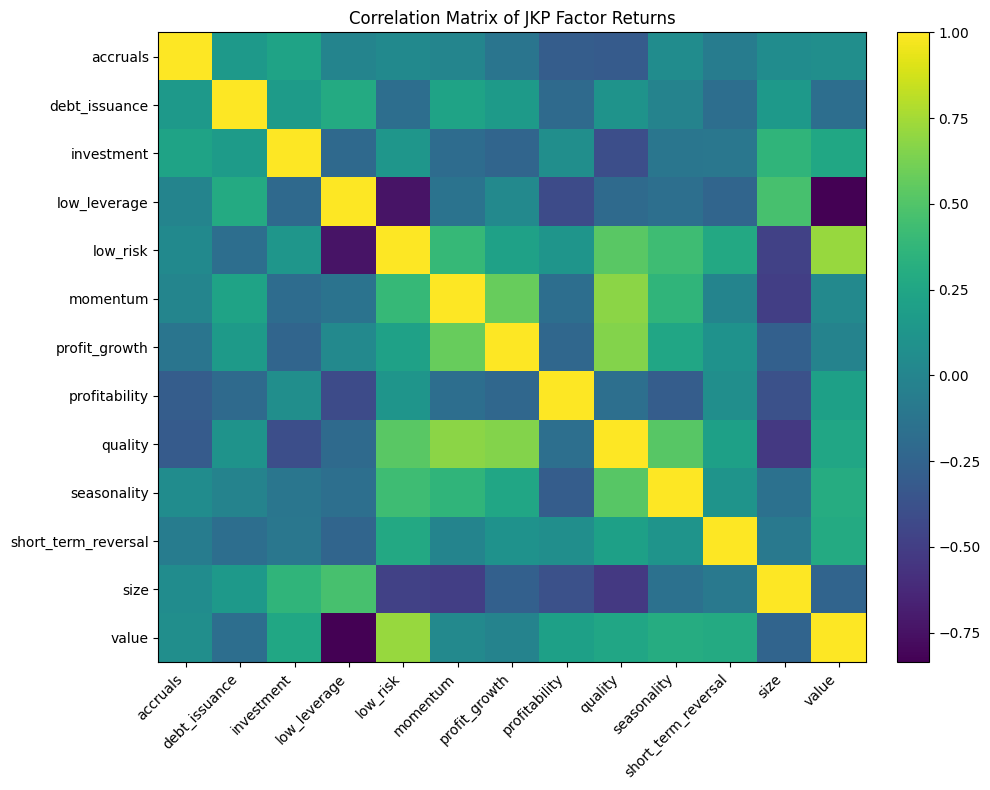

In [19]:
factor_corr = jkp_factors.corr()

display(factor_corr)

plt.figure(figsize=(10, 8))
im = plt.imshow(factor_corr, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(factor_corr.columns)), factor_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(factor_corr.index)), factor_corr.index)
plt.title("Correlation Matrix of JKP Factor Returns")
plt.tight_layout()
plt.show()

## Rolling Factor Performance

Factor returns vary through time.

The code below computes rolling annualized means and volatilities using a 60-month window.

This lets students see that factor performance is not stable across every subperiod.

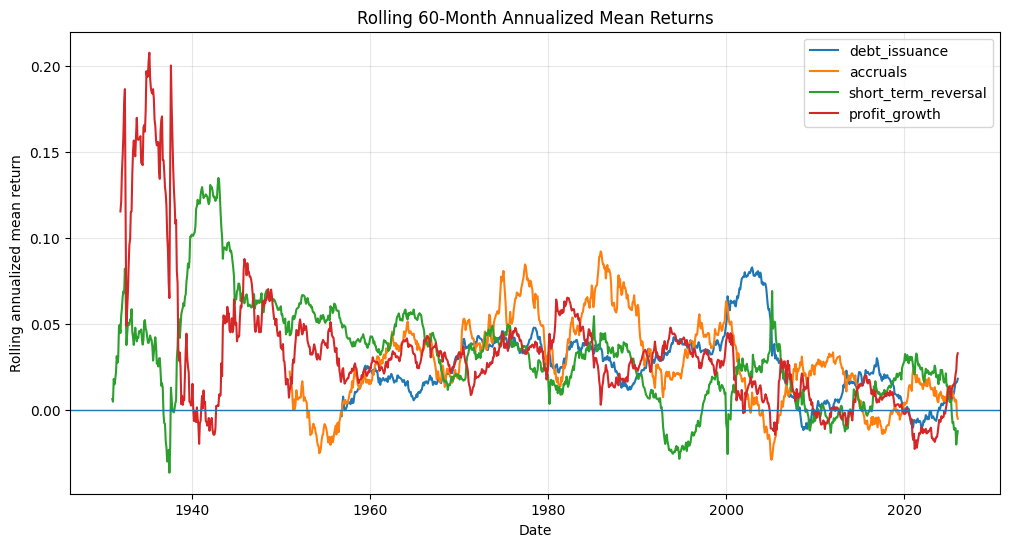

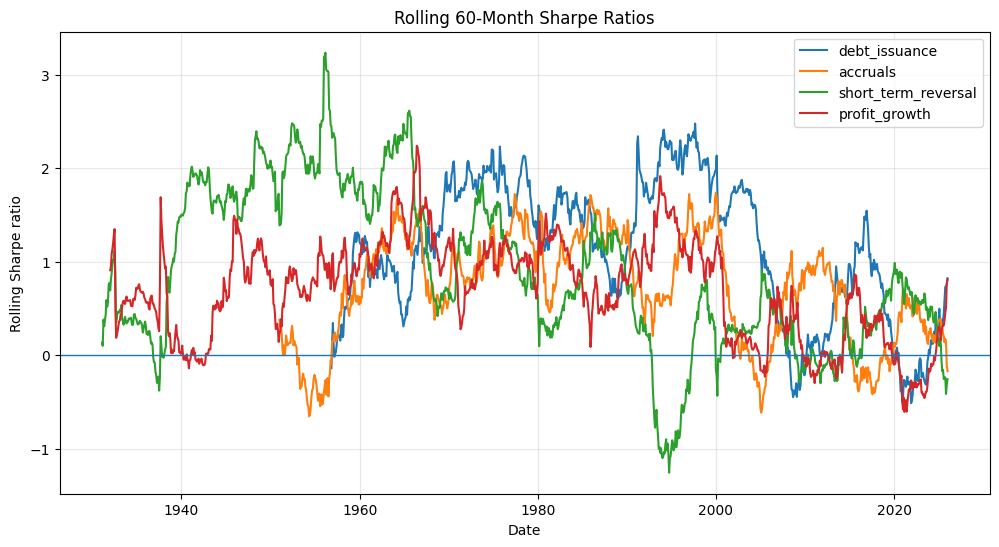

In [20]:
rolling_window = 60

rolling_mean = jkp_factors.rolling(rolling_window).mean() * 12
rolling_vol = jkp_factors.rolling(rolling_window).std(ddof=1) * np.sqrt(12)
rolling_sharpe = rolling_mean / rolling_vol

plot_cols = top_factors[:4]

plt.figure(figsize=(12, 6))
for col in plot_cols:
    plt.plot(rolling_mean.index, rolling_mean[col], label=col)
plt.axhline(0, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Rolling annualized mean return")
plt.title("Rolling 60-Month Annualized Mean Returns")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
for col in plot_cols:
    plt.plot(rolling_sharpe.index, rolling_sharpe[col], label=col)
plt.axhline(0, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe ratio")
plt.title("Rolling 60-Month Sharpe Ratios")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Drawdowns of Factor Strategies

A factor can have a positive average return and still suffer large drawdowns.

Drawdown is defined as the percentage decline from a previous peak:

$$
DD_t = \frac{W_t}{\max_{s \le t} W_s}-1.
$$

,Max Drawdown
name,
quality,-0.8672
momentum,-0.8515
low_risk,-0.8124
low_leverage,-0.7056
value,-0.6196
profit_growth,-0.5593
size,-0.4652
seasonality,-0.3670
profitability,-0.3472


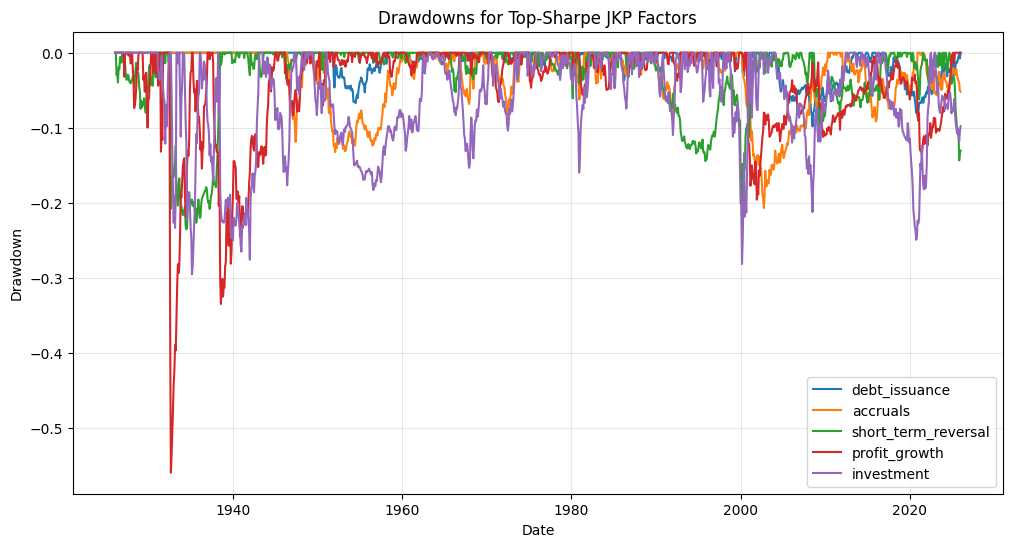

In [21]:
def drawdown_from_returns(r):
    wealth = (1 + r.fillna(0)).cumprod()
    peak = wealth.cummax()
    return wealth / peak - 1

drawdowns = jkp_factors.apply(drawdown_from_returns)

max_drawdown = drawdowns.min().sort_values()
display(pd.DataFrame({"Max Drawdown": max_drawdown}))

plt.figure(figsize=(12, 6))
for col in top_factors[:5]:
    plt.plot(drawdowns.index, drawdowns[col], label=col)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Drawdowns for Top-Sharpe JKP Factors")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Regression of One Factor on Other Factors

To illustrate factor redundancy, regress one factor on several others.

If a factor's returns are well explained by other factors, its apparent premium may not represent a distinct source of return.

The intercept is an alpha relative to the chosen factor model.

In [22]:
def factor_regression(y, X):
    y = pd.Series(y).dropna()
    X = pd.DataFrame(X).loc[y.index].dropna()
    y = y.loc[X.index]

    Xmat = np.column_stack([np.ones(len(X)), X.values])
    coef = np.linalg.inv(Xmat.T @ Xmat) @ Xmat.T @ y.values
    fitted = Xmat @ coef
    resid = y.values - fitted

    n, k = Xmat.shape
    s2 = resid @ resid / (n - k)
    cov = s2 * np.linalg.inv(Xmat.T @ Xmat)
    se = np.sqrt(np.diag(cov))
    tstat = coef / se

    table = pd.DataFrame({
        "Coefficient": coef,
        "Std Error": se,
        "t-stat": tstat
    }, index=["Alpha"] + list(X.columns))

    r2 = 1 - (resid @ resid) / ((y.values - y.values.mean()) @ (y.values - y.values.mean()))
    return table, pd.Series(resid, index=y.index, name="Residual"), r2

# Example: explain momentum using several other factors if available.
target = "momentum" if "momentum" in jkp_factors.columns else jkp_factors.columns[0]
candidate_controls = [c for c in ["value", "size", "investment", "profitability", "quality", "low_risk"] if c in jkp_factors.columns]

print("Target factor:", target)
print("Control factors:", candidate_controls)

if len(candidate_controls) >= 2:
    reg_table, residuals, r2 = factor_regression(jkp_factors[target], jkp_factors[candidate_controls])
    display(reg_table)
    print(f"R-squared: {r2:.4f}")
else:
    print("Not enough standard control factors found for the regression example.")

Target factor: momentum
Control factors: ['value', 'size', 'investment', 'profitability', 'quality', 'low_risk']


,Coefficient,Std Error,t-stat
Alpha,0.0033,0.0008,4.3651
value,-0.4222,0.0357,-11.8387
size,-0.4792,0.0388,-12.3350
investment,0.3284,0.0349,9.4062
profitability,-0.3316,0.0402,-8.2511
quality,0.5814,0.0319,18.2252
low_risk,0.1757,0.0343,5.1238


R-squared: 0.5922


## A Simple Multifactor Portfolio Experiment

The next cell forms an equal-weighted portfolio of several historically high-Sharpe factors.

This is not an investment recommendation. It is a teaching example showing how factor diversification can be analyzed with the same tools used for asset portfolios.

,Equal-Weighted Top-Factor Combo
Mean Ann. Return,0.0334
Ann. Volatility,0.0371
Sharpe Ratio,0.9007
Skewness,0.9524
Excess Kurtosis,29.0696
Worst Monthly Return,-0.0883
Max Drawdown,-0.1577


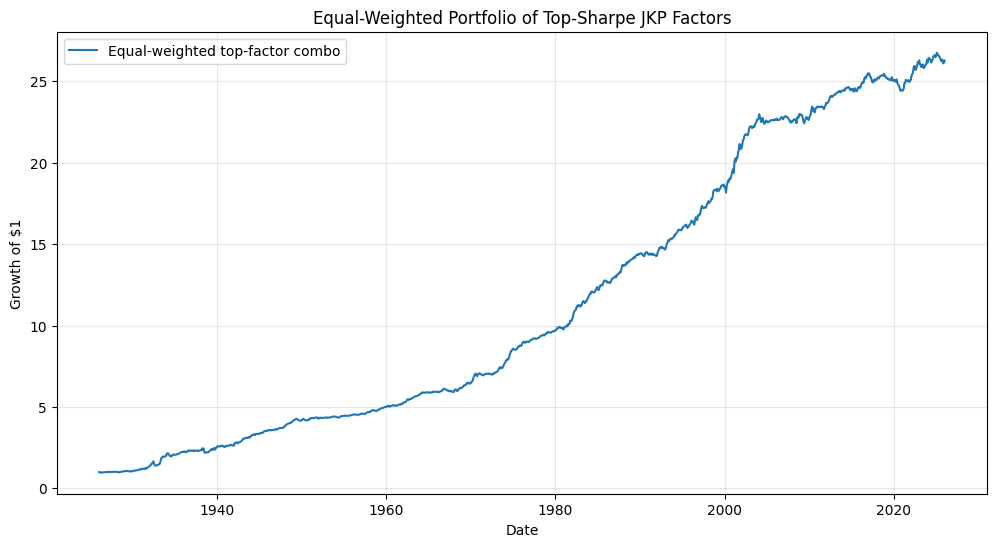

In [23]:
selected = top_factors[:5]
factor_combo = jkp_factors[selected].mean(axis=1)

combo_summary = pd.Series({
    "Mean Ann. Return": factor_combo.mean() * 12,
    "Ann. Volatility": factor_combo.std(ddof=1) * np.sqrt(12),
    "Sharpe Ratio": (factor_combo.mean() * 12) / (factor_combo.std(ddof=1) * np.sqrt(12)),
    "Skewness": factor_combo.skew(),
    "Excess Kurtosis": factor_combo.kurtosis(),
    "Worst Monthly Return": factor_combo.min(),
    "Max Drawdown": drawdown_from_returns(factor_combo).min()
})

display(combo_summary.to_frame("Equal-Weighted Top-Factor Combo"))

combo_wealth = (1 + factor_combo.fillna(0)).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(combo_wealth.index, combo_wealth, label="Equal-weighted top-factor combo")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("Equal-Weighted Portfolio of Top-Sharpe JKP Factors")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Spurious Factor Discovery Revisited with Real Factor Context

This data file contains a modest number of broad factor themes, not hundreds of arbitrary mined signals.

Still, the factor-zoo warning remains important.

If researchers examine many candidate factors, many portfolio constructions, many regions, many weighting schemes, many sample periods, and many definitions of signals, some results will look impressive by chance.

The correct empirical discipline is to combine:

1. economic motivation,
2. out-of-sample validation,
3. robustness across markets,
4. transaction-cost analysis,
5. realistic capacity constraints,
6. caution about multiple testing.

# Part VIII. Simulation: How Spurious Factors Arise

The factor zoo creates an econometric danger.

If we test hundreds of candidate factors, some will look significant purely by chance. This is not a criticism of factor modeling itself. It is a warning about data mining and multiple testing.

In [24]:
np.random.seed(777)
T = 240
num_fake_factors = 500
num_simulations = 200

def simple_t_stat(y, x):
    X = np.column_stack([np.ones(len(x)), x])
    bhat = np.linalg.inv(X.T @ X) @ X.T @ y
    resid = y - X @ bhat
    n, k = X.shape
    s2 = resid @ resid / (n-k)
    cov = s2 * np.linalg.inv(X.T @ X)
    return bhat[1] / np.sqrt(cov[1, 1])

max_abs_t = []
significant_counts = []

for _ in range(num_simulations):
    y = np.random.normal(0, 1, T)
    tstats = np.array([simple_t_stat(y, np.random.normal(0, 1, T)) for _ in range(num_fake_factors)])
    max_abs_t.append(np.max(np.abs(tstats)))
    significant_counts.append(np.sum(np.abs(tstats) > 1.96))

spurious = pd.DataFrame({
    "Average number of false |t|>1.96 discoveries": [np.mean(significant_counts)],
    "Median number of false |t|>1.96 discoveries": [np.median(significant_counts)],
    "Average maximum |t|": [np.mean(max_abs_t)],
    "95th percentile maximum |t|": [np.quantile(max_abs_t, 0.95)]
})
spurious

,Average number of false |t|>1.96 discoveries,Median number of false |t|>1.96 discoveries,Average maximum |t|,95th percentile maximum |t|
0,25.8550,26.0000,3.2604,3.8007


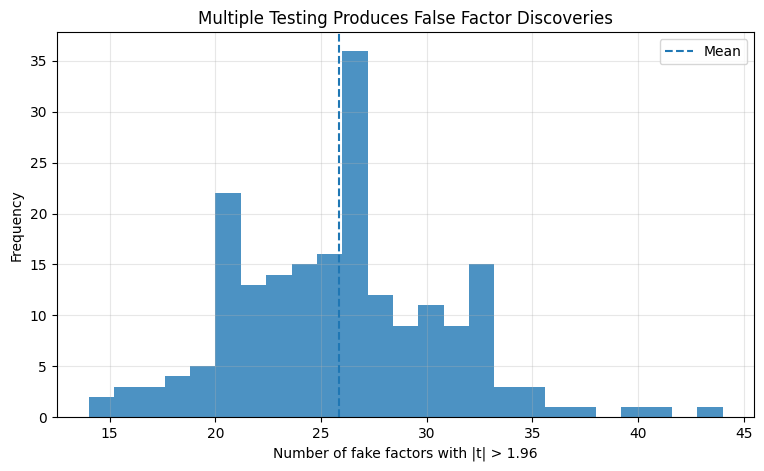

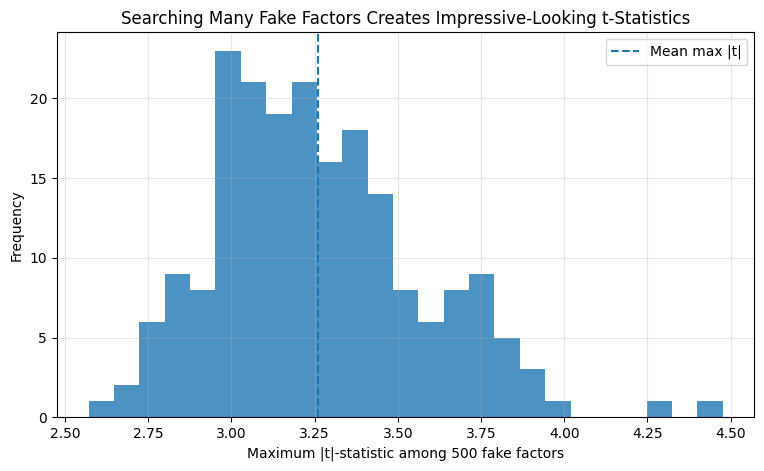

In [25]:
plt.figure(figsize=(9,5))
plt.hist(significant_counts, bins=25, alpha=0.8)
plt.axvline(np.mean(significant_counts), linestyle="--", label="Mean")
plt.xlabel("Number of fake factors with |t| > 1.96")
plt.ylabel("Frequency")
plt.title("Multiple Testing Produces False Factor Discoveries")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))
plt.hist(max_abs_t, bins=25, alpha=0.8)
plt.axvline(np.mean(max_abs_t), linestyle="--", label="Mean max |t|")
plt.xlabel("Maximum |t|-statistic among 500 fake factors")
plt.ylabel("Frequency")
plt.title("Searching Many Fake Factors Creates Impressive-Looking t-Statistics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Interpretation

In this simulation, every candidate factor is fake. There is no true relationship.

Yet the search still finds factors with apparently impressive t-statistics.

This is why empirical factor research should ask whether a factor:

1. has a clear economic mechanism,
2. survives out-of-sample tests,
3. works outside the original sample and region,
4. survives realistic transaction costs,
5. survives appropriate multiple-testing adjustments,
6. is implementable at realistic scale.

# 26. Key Formulas

## Single-factor return model

$$
R_i = \mathbb{E}[R_i]+\beta_iF+\epsilon_i
$$

## Single-factor APT expected return

$$
\mathbb{E}[R_i]=R_f+\beta_i\lambda
$$

## Multifactor APT expected return

$$
\mathbb{E}[R_i]=R_f+\sum_{k=1}^K \beta_{ik}\lambda_k
$$

## Factor covariance

$$
\operatorname{Cov}(R_i,R_j)=\beta_i\beta_j\sigma_F^2
$$

## Multifactor covariance

$$
\operatorname{Cov}(R_i,R_j)=\sum_{k=1}^K \beta_{ik}\beta_{jk}\sigma_{F_k}^2
$$

if factors are uncorrelated.

## Zero-net-investment portfolio

$$
\sum_i w_i = 0
$$

## Zero-factor-exposure portfolio

$$
\sum_i w_i\beta_{ik}=0 \quad \text{for every factor } k
$$

## Fama-French three-factor model

$$
R_i-R_f=\alpha_i+\beta_{iM}(R_M-R_f)+s_iSMB+h_iHML+\epsilon_i
$$

# 27. Final Takeaways

1. Arbitrage is stronger than a favorable risk-return tradeoff.
2. The law of one price requires identical payoffs to have identical prices.
3. APT assumes returns are driven by common factors plus diversifiable residuals.
4. Factor betas measure exposure to systematic risk factors.
5. Well-diversified portfolios eliminate most idiosyncratic risk.
6. APT expected returns are linear in factor betas.
7. Multifactor APT generalizes CAPM by allowing many priced risks.
8. APT is most exact for diversified portfolios and approximate for individual securities.
9. Factor models can estimate cost of capital for firms and projects.
10. Fama-French-style models are empirical implementations of multifactor pricing ideas.
11. The factor zoo warns against confusing data mining with true priced risk.
12. Smart beta is systematic factor tilting in portfolio form.

# 28. Short Reference Guide

Core sources for this lecture include:

- Ross, Stephen A. 1976. “The Arbitrage Theory of Capital Asset Pricing.”
- Fama, Eugene F., and Kenneth R. French. 1993. “Common Risk Factors in the Returns on Stocks and Bonds.”
- Carhart, Mark M. 1997. “On Persistence in Mutual Fund Performance.”
- Fama, Eugene F., and Kenneth R. French. 2015. “A Five-Factor Asset Pricing Model.”
- Hou, Kewei, Chen Xue, and Lu Zhang. 2015. “Digesting Anomalies: An Investment Approach.”
- Harvey, Campbell R., Yan Liu, and Heqing Zhu. 2016. “...and the Cross-Section of Expected Returns.”

For empirical work, pair the no-arbitrage logic with careful data handling: check dates, units, missing values, rebalancing conventions, transaction costs, and whether a factor was discovered before or after the evaluation sample.